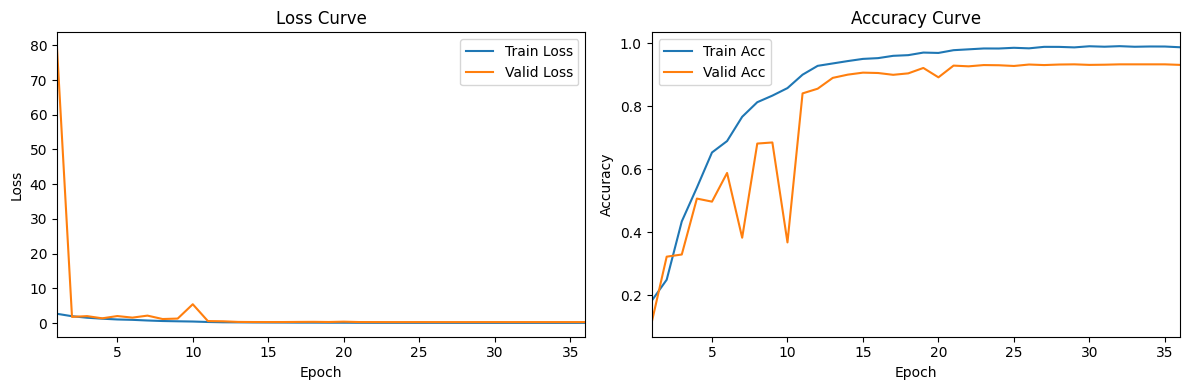

Epoch 36/36 │ Train Loss: 0.0444, Train Acc: 0.9873 │ Valid Loss: 0.2670, Valid Acc: 0.9313

Evaluating Model 1 (C:\Users\nihao\Desktop\urSound\best_models\epoch029_acc0.9330.pth) with Valid Acc=0.9330


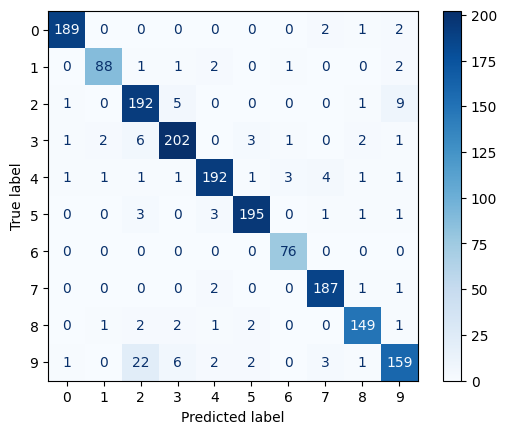

In [2]:
import os
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch.optim import lr_scheduler
from torch.cuda.amp import GradScaler, autocast  # 使用 CUDA AMP
import pandas as pd
from IPython.display import clear_output, display

# -----------------------
# 全局配置
# -----------------------
root_dir    = r"C:\Users\nihao\Desktop\urSound\UrbanSound8K"
sample_rate = 32000
duration    = 4.0
num_samples = int(sample_rate * duration)
batch_size  = 256
num_epochs  = 36
lr          = 0.01
top_n       = 1   # 保留最好的 1 个模型

best_model_dir = os.path.join(os.path.dirname(root_dir), 'best_models')
os.makedirs(best_model_dir, exist_ok=True)

# -------------------------------------------------------
# 1. 数据集类
# -------------------------------------------------------
class UrbanSoundDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.metadata  = pd.read_csv(os.path.join(root_dir, 'metadata', 'UrbanSound8k.csv'))

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        info     = self.metadata.iloc[idx]
        fold     = info['fold']
        fname    = info['slice_file_name']
        path     = os.path.join(self.root_dir, 'audio', f'fold{fold}', fname)
        if not os.path.exists(path):
            return torch.tensor([]), -1

        audio, sr = librosa.load(path, sr=sample_rate)
        if len(audio) < num_samples:
            audio = np.pad(audio, (0, num_samples - len(audio)), 'constant')
        else:
            audio = audio[:num_samples]

        S    = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=512,
                                              hop_length=64, n_mels=64,
                                              fmin=0, fmax=sr//2)
        S_db = librosa.power_to_db(S, ref=np.max)
        img  = np.stack([S_db, S_db, S_db], axis=-1)

        if self.transform:
            img = self.transform(img)

        label = info['classID']
        return img, label

def collate_fn(batch):
    batch = [b for b in batch if b[1] != -1]
    if not batch:
        return torch.tensor([]), torch.tensor([])
    return torch.utils.data.default_collate(batch)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

dataset         = UrbanSoundDataset(root_dir, transform=transform)
train_size      = int(0.8 * len(dataset))
valid_size      = len(dataset) - train_size
train_dataset, valid_dataset = random_split(dataset, [train_size, valid_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size,
                          shuffle=False, collate_fn=collate_fn)

# -------------------------------------------------------
# 2. 模型定义
# -------------------------------------------------------
class AudioResNet18(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=7,
                                      stride=2, padding=3, bias=False)
        self.resnet.fc    = nn.Linear(self.resnet.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)

device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

num_classes = 10
net         = AudioResNet18(num_classes).to(device)

# -------------------------------------------------------
# 3. 训练与验证函数（动态绘图 + Top-N 保存）
# -------------------------------------------------------
def train_and_validate(net, train_loader, valid_loader,
                       num_epochs, lr, device, top_n=1):
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    scaler    = GradScaler()

    train_losses, valid_losses = [], []
    train_accs,   valid_accs   = [], []
    best_models = []

    for epoch in range(1, num_epochs + 1):
        # 训练
        net.train()
        sum_loss = correct = total = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            with autocast():
                out  = net(X)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            sum_loss += loss.item() * y.size(0)
            preds    = out.argmax(dim=1)
            correct  += (preds == y).sum().item()
            total    += y.size(0)
        train_loss = sum_loss / total
        train_acc  = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # 验证
        net.eval()
        sum_loss = correct = total = 0
        with torch.no_grad():
            for X, y in valid_loader:
                X, y = X.to(device), y.to(device)
                out   = net(X)
                loss  = criterion(out, y)
                sum_loss += loss.item() * y.size(0)
                preds    = out.argmax(dim=1)
                correct  += (preds == y).sum().item()
                total    += y.size(0)
        valid_loss = sum_loss / total
        valid_acc  = correct / total
        valid_losses.append(valid_loss)
        valid_accs.append(valid_acc)

        scheduler.step()

        # 保存 Top-N
        path = os.path.join(best_model_dir,
                            f"epoch{epoch:03d}_acc{valid_acc:.4f}.pth")
        torch.save(net.state_dict(), path)
        best_models.append((valid_acc, path))
        best_models = sorted(best_models, key=lambda x: x[0], reverse=True)[:top_n]
        for _, extra in best_models[top_n:]:
            if os.path.exists(extra):
                os.remove(extra)

        # 动态绘图
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(range(1, epoch+1), train_losses, label='Train Loss')
        axes[0].plot(range(1, epoch+1), valid_losses, label='Valid Loss')
        axes[0].set_title('Loss Curve')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].legend(); axes[0].set_xlim(1, num_epochs)

        axes[1].plot(range(1, epoch+1), train_accs, label='Train Acc')
        axes[1].plot(range(1, epoch+1), valid_accs, label='Valid Acc')
        axes[1].set_title('Accuracy Curve')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
        axes[1].legend(); axes[1].set_xlim(1, num_epochs)

        plt.tight_layout()
        display(fig)
        plt.close(fig)

        # 文本输出
        print(
            f"Epoch {epoch}/{num_epochs} │ "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} │ "
            f"Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}",
            flush=True
        )

    return best_models

# -------------------------------------------------------
# 4. 运行训练
# -------------------------------------------------------
best_models = train_and_validate(
    net, train_loader, valid_loader,
    num_epochs, lr, device, top_n
)

# -------------------------------------------------------
# 5. 评估并绘制混淆矩阵
# -------------------------------------------------------
def evaluate_accuracy(loader, net, device):
    net.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out  = net(X)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=np.arange(num_classes))
    disp.plot(cmap='Blues')
    plt.show()

for idx, (acc, path) in enumerate(best_models):
    print(f"\nEvaluating Model {idx+1} ({path}) with Valid Acc={acc:.4f}")
    net.load_state_dict(torch.load(path, map_location=device))
    evaluate_accuracy(valid_loader, net, device)


In [1]:
import os
import numpy as np
import librosa
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch.optim import lr_scheduler
from torch.amp import GradScaler, autocast
import pandas as pd

# ----------------------------------
# 1. 参数设置
# ----------------------------------
root_dir = r"C:\Users\nihao\Desktop\urSound\UrbanSound8K"
sample_rate = 32000      # librosa 会自动提取采样率，这里设定默认采样率
duration = 4.0           # UrbanSound8K 的音频时长最长为 4 秒
num_samples = int(sample_rate * duration)
batch_size = 1024
num_epochs = 10
lr = 0.0018
top_n = 10  # 保存最好的 top_n 个模型

# 创建最佳模型的保存路径
best_model_dir = os.path.join(os.path.dirname(root_dir), 'best_models')
os.makedirs(best_model_dir, exist_ok=True)

# ----------------------------------
# 2. 数据集类定义
# ----------------------------------
class UrbanSoundDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.metadata = pd.read_csv(os.path.join(root_dir, 'metadata', 'UrbanSound8k.csv'))
    
    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        audio_info = self.metadata.iloc[idx]
        fold = audio_info['fold']
        file_name = audio_info['slice_file_name']
        file_path = os.path.join(self.root_dir, 'audio', f'fold{fold}', file_name)
    
        # 文件不存在时，跳过
        if not os.path.exists(file_path):
            return torch.tensor([]), -1  # 返回空数据和无效标签
    
        try:
            # 加载音频文件并自动提取采样率
            audio, sr = librosa.load(file_path, sr=sample_rate)
        except Exception as e:
            print(f"加载文件时发生错误: {file_path}, 错误信息: {e}")
            return torch.tensor([]), -1  # 返回空数据和无效标签
    
        # 填充或截断音频到固定长度
        if len(audio) < num_samples:
            audio = np.pad(audio, (0, num_samples - len(audio)), 'constant')
        else:
            audio = audio[:num_samples]
    
        # 转换为 Mel 频谱图
        S = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_fft=512, hop_length=64, n_mels=64, fmin=0, fmax=sr//2
        )
        S_db = librosa.power_to_db(S, ref=np.max)
    
        # 将 Mel 频谱图转换为 3 通道图像（重复 3 次以适配 ResNet18）
        img = np.stack([S_db, S_db, S_db], axis=-1)
    
        # 归一化并转换为张量
        if self.transform:
            img = self.transform(img)
    
        label = audio_info['classID']
        return img, label

# 自定义的 collate_fn，用于过滤空数据
def collate_fn(batch):
    batch = [item for item in batch if item[1] != -1]
    if len(batch) == 0:
        return torch.tensor([]), torch.tensor([])
    return torch.utils.data.default_collate(batch)

# ----------------------------------
# 3. 数据预处理 & 加载
# ----------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = UrbanSoundDataset(root_dir=root_dir, transform=transform)

# 按 80% : 20% 划分训练集和验证集（如需训练可以使用）
train_size = int(0.80 * len(dataset))
valid_size = len(dataset) - train_size
train_dataset, valid_dataset = random_split(dataset, [train_size, valid_size])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# ----------------------------------
# 4. 定义模型：ResNet18
# ----------------------------------
class AudioResNet18(nn.Module):
    def __init__(self, num_classes):
        super(AudioResNet18, self).__init__()
        # 使用新的官方权重
        self.resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.resnet.conv1 = nn.Conv2d(
            3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        )
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)

# 选择设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 实例化模型
num_classes = 10  # UrbanSound8K 有 10 个类别
net = AudioResNet18(num_classes).to(device)

# ----------------------------------
# 5. 训练与验证（可选，如不需要重新训练可跳过）
# ----------------------------------
def train_and_validate(net, train_loader, valid_loader, num_epochs, lr, device):
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    best_models = []
    
    for epoch in range(num_epochs):
        net.train()
        total_loss = 0
        correct_train = 0
        total_train = 0
        
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            # 混合精度加速训练
            with autocast(device_type='cuda', enabled=(device.type=='cuda')):
                outputs = net(features)
                loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_acc = correct_train / total_train

        # 验证
        net.eval()
        valid_loss = 0
        correct_valid = 0
        total_valid = 0
        
        with torch.no_grad():
            for features, labels in valid_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = net(features)
                loss = criterion(outputs, labels)
                valid_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct_valid += (predicted == labels).sum().item()
                total_valid += labels.size(0)

        valid_acc = correct_valid / total_valid
        scheduler.step()

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}, "
              f"Valid Loss: {valid_loss/len(valid_loader):.4f}, Valid Acc: {valid_acc:.4f}")

        # 保存模型
        current_model_path = os.path.join(best_model_dir, f"model_epoch_{epoch+1}_acc_{valid_acc:.4f}.pth")
        torch.save(net.state_dict(), current_model_path)
        best_models.append((valid_acc, current_model_path))

        # 只保留 top_n 个最优模型
        best_models = sorted(best_models, key=lambda x: x[0], reverse=True)
        if len(best_models) > top_n:
            _, worst_model_path = best_models.pop(-1)
            if os.path.exists(worst_model_path):
                os.remove(worst_model_path)

    return best_models

# ----------------------------------
# 6. 定义「平均准确率」评估函数（按类别，再求平均）
# ----------------------------------
def evaluate_classwise_accuracy(data_loader, net, device, num_classes=10):
    """
    计算每个类别的准确率，并返回它们的算术平均值
    """
    net.eval()
    # 用于统计每个类别的 [正确预测数, 总数]
    class_correct = [0] * num_classes
    class_total = [0] * num_classes

    with torch.no_grad():
        for features, labels in data_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = net(features)
            _, predicted = torch.max(outputs, 1)
            for label, pred in zip(labels, predicted):
                class_total[label.item()] += 1
                if label.item() == pred.item():
                    class_correct[label.item()] += 1
    
    # 计算每个类别准确率
    class_accuracies = []
    for i in range(num_classes):
        if class_total[i] == 0:
            acc = 0.0
        else:
            acc = class_correct[i] / class_total[i]
        class_accuracies.append(acc)

    # 计算每个类别准确率的平均值
    average_accuracy = sum(class_accuracies) / num_classes

    return class_accuracies, average_accuracy

# ----------------------------------
# 7. 主程序：使用全部数据集进行「平均准确率」评估
# ----------------------------------
if __name__ == "__main__":
    # 如果想重新训练，可以取消注释以下行
    # best_models = train_and_validate(net, train_dataloader, valid_dataloader, num_epochs, lr, device)
    
    # ======== 加载已有模型参数（无需重新训练） ========
    checkpoint_path = r"C:\Users\nihao\Desktop\urSound\best_models\model_epoch_9_acc_0.8901.pth"
    net.load_state_dict(torch.load(checkpoint_path, map_location=device))
    
    # ======== 重点修改：使用「整个数据集」进行评估 ========
    # 构建一个 eval_dataloader，直接使用完整的 dataset
    eval_dataloader = DataLoader(
        dataset,            # 使用所有数据
        batch_size=batch_size,
        shuffle=False,      # 评估时通常不需要打乱
        collate_fn=collate_fn
    )
    
    # 使用该模型在「整个数据集」上计算「每个类别的准确率」和「平均准确率」
    class_accuracies, mean_accuracy = evaluate_classwise_accuracy(eval_dataloader, net, device, num_classes=num_classes)
    
    print("\n【在整个 UrbanSound8K 数据集上的每个类别准确率】")
    for i, acc in enumerate(class_accuracies):
        print(f"  类别 {i}: {acc*100:.2f}%")

    print(f"\n【在整个 UrbanSound8K 数据集上的平均准确率】= {mean_accuracy*100:.2f}%")


Using device: cuda

【在整个 UrbanSound8K 数据集上的每个类别准确率】
  类别 0: 97.00%
  类别 1: 96.03%
  类别 2: 94.80%
  类别 3: 94.88%
  类别 4: 97.20%
  类别 5: 91.40%
  类别 6: 100.00%
  类别 7: 81.60%
  类别 8: 89.88%
  类别 9: 73.80%

【在整个 UrbanSound8K 数据集上的平均准确率】= 91.66%
